In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Step 1: Create a Sample Dataset
np.random.seed(42)
data = {
    'id': range(1, 21),
    'name': [f'Student_{i}' for i in range(1, 21)],
    'gender': np.random.choice(['Male', 'Female'], 20),
    'age': np.random.randint(18, 25, 20),
    'class': np.random.choice(['sr', 'jr'], 20),
    'cgpa': np.random.uniform(2.0, 4.0, 20),
    'attendance': np.random.uniform(50, 100, 20),
    'test_score': np.random.randint(50, 100, 20),
    'dept': np.random.choice(['CS', 'Math', 'Physics', 'Chemistry'], 20)
}
df = pd.DataFrame(data)

In [3]:
df

,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics
3,4,Student_4,Male,21,jr,3.931264,79.894999,60,Math
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics
7,8,Student_8,Male,21,jr,3.368466,52.261364,84,Chemistry
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math


In [4]:
# Introduce some missing values and inconsistencies
df.loc[3, 'cgpa'] = np.nan  # Missing CGPA value
df.loc[7, 'attendance'] = -5  # Invalid attendance
df

,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics
3,4,Student_4,Male,21,jr,NaN,79.894999,60,Math
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics
7,8,Student_8,Male,21,jr,3.368466,-5.000000,84,Chemistry
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math


In [5]:
# Step 2: Handling Missing Values
# Fill missing values in 'cgpa' with the mean
cgpa_mean = df['cgpa'].mean()
df['cgpa'].fillna(cgpa_mean, inplace=True)
df

,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics
3,4,Student_4,Male,21,jr,2.898388,79.894999,60,Math
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics
7,8,Student_8,Male,21,jr,3.368466,-5.000000,84,Chemistry
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math


In [6]:
# Step 3: Handling Inconsistencies
# Correct negative attendance values
for i in df.index:
    if df.loc[i, 'attendance'] < 0:
        df.loc[i, 'attendance'] = df['attendance'].median()
df

,id,name,gender,age,class,cgpa,attendance,test_score,dept
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics
3,4,Student_4,Male,21,jr,2.898388,79.894999,60,Math
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics
7,8,Student_8,Male,21,jr,3.368466,73.284334,84,Chemistry
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math


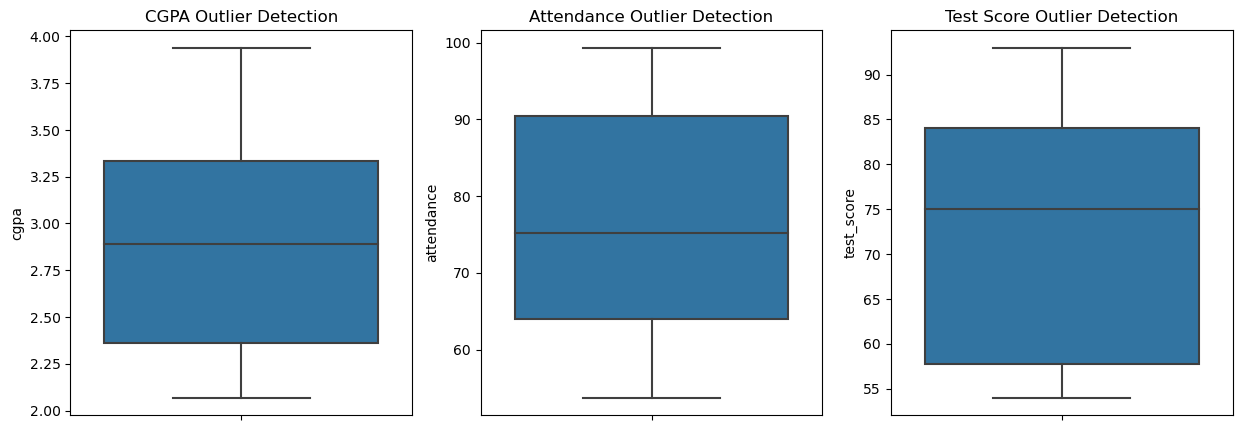

In [7]:
# Step 4: Detecting Outliers
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['cgpa'], ax=ax[0])
sns.boxplot(y=df['attendance'], ax=ax[1])
sns.boxplot(y=df['test_score'], ax=ax[2])
ax[0].set_title("CGPA Outlier Detection")
ax[1].set_title("Attendance Outlier Detection")
ax[2].set_title("Test Score Outlier Detection")
plt.show()

In [8]:
# Remove outliers using IQR
for col in ['cgpa', 'attendance', 'test_score']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [9]:
# Step 5: Data Transformation (Normalize attendance for better interpretability)
scaler = MinMaxScaler()
df['attendance_scaled'] = scaler.fit_transform(df[['attendance']])

In [10]:
df

,id,name,gender,age,class,cgpa,attendance,test_score,dept,attendance_scaled
0,1,Student_1,Male,23,jr,2.341048,88.756641,93,Chemistry,0.767899
1,2,Student_2,Female,22,jr,2.130103,96.974947,57,Physics,0.948059
2,3,Student_3,Male,19,jr,3.897771,94.741368,73,Physics,0.899095
3,4,Student_4,Male,21,jr,2.898388,79.894999,60,Math,0.573636
4,5,Student_5,Male,23,jr,3.616795,96.093712,66,Chemistry,0.928740
5,6,Student_6,Female,23,sr,2.609228,54.424625,57,CS,0.015281
6,7,Student_7,Male,19,jr,2.195344,59.799143,84,Physics,0.133100
7,8,Student_8,Male,21,jr,3.368466,73.284334,84,Chemistry,0.428719
8,9,Student_9,Male,22,sr,2.880305,66.266517,82,Chemistry,0.274876
9,10,Student_10,Female,18,jr,2.244076,69.433864,54,Math,0.344310


In [11]:
# Print cleaned dataset
print(df.head())

   id       name  gender  age class      cgpa  attendance  test_score  \
0   1  Student_1    Male   23    jr  2.341048   88.756641          93   
1   2  Student_2  Female   22    jr  2.130103   96.974947          57   
2   3  Student_3    Male   19    jr  3.897771   94.741368          73   
3   4  Student_4    Male   21    jr  2.898388   79.894999          60   
4   5  Student_5    Male   23    jr  3.616795   96.093712          66   

        dept  attendance_scaled  
0  Chemistry           0.767899  
1    Physics           0.948059  
2    Physics           0.899095  
3       Math           0.573636  
4  Chemistry           0.928740  


In [12]:
df.skew()

C:\Users\diyas\AppData\Local\Temp\ipykernel_5204\1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


id                   0.000000
age                 -0.120193
cgpa                 0.364026
attendance           0.016610
test_score          -0.009442
attendance_scaled    0.016610
dtype: float64

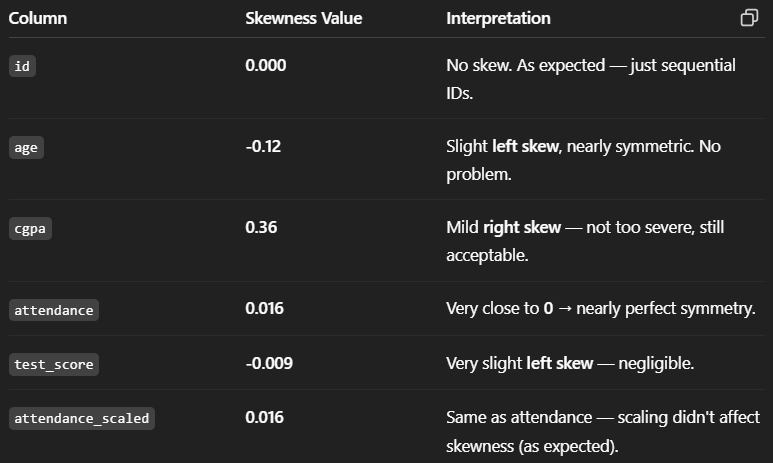